### Specifications Overview
Using the sample dataset provided, calculate the 30 day simple moving average for AAPLs stock price.
Graph this as a line graph on top of AAPLs stock price chart to visualize what is happening, and get a list of the historical days in which you could’ve bought the stock (according to the mean reversion algorithm) and a list of the historical days in which you could’ve sold the stock (according to the mean reversion algorithm).
Finally, return a buy day and a sell day out of the days gathered above, that maximize the profit you can make.


In [4]:
# importing modules to use
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

In [54]:
# reading data to var
data = pd.read_csv('AAPL.csv')
data = data.set_index("Date")

data

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2021-10-27,149.360001,149.729996,148.490005,148.850006,148.020569,56094900
2021-10-28,149.820007,153.169998,149.720001,152.570007,151.719818,100077900
2021-10-29,147.220001,149.940002,146.410004,149.800003,148.965271,124953200
2021-11-01,148.990005,149.699997,147.800003,148.960007,148.129959,74588300
2021-11-02,148.660004,151.570007,148.649994,150.020004,149.184052,69122000
...,...,...,...,...,...,...
2022-10-21,142.869995,147.850006,142.649994,147.270004,147.270004,86464700
2022-10-24,147.190002,150.229996,146.000000,149.449997,149.449997,75981900
2022-10-25,150.089996,152.490005,149.360001,152.339996,152.339996,74732300


204


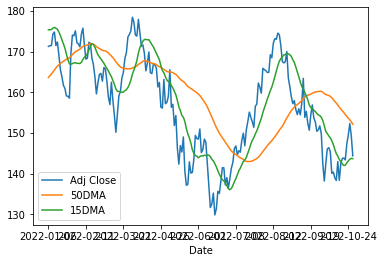

In [55]:
data = data["Adj Close"].to_frame()
data2 = data
data["15DMA"] = data["Adj Close"].rolling(15).mean()
data["50DMA"] = data["Adj Close"].rolling(50).mean()

data.dropna(inplace = True)
data[["Adj Close", "50DMA", "15DMA"]].plot()
print(len(data))
# data["Action"] = "Hold"
# # data.loc[data['30DMA'] < data["Adj Close"], "Action"] = "Buy"
# # data.loc[data['30DMA'] > data["Adj Close"], "Action"] = "Sell"
# higher = True
# data["Actions"] = "Hold"
# for i in range(len(data)):
#   if not higher and data['30DMA'][i] > data['50DMA'][i]:
#     higher = True
#     data["Actions"][i] = 'Buy'
#   elif higher and data['30DMA'][i] < data['50DMA'][i]:
#     higher = False
#     data["Actions"][i] = 'Sell'
#   else:
#     data["Actions"][i] = 'Hold'


In [22]:
import math
#data = data.reset_index()
best_buy = math.inf
best_day = -1
best_sell = -math.inf
best_sday = -1
best_diff = -math.inf
actual = (best_day, best_sday)
for i in range (len(data["Adj Close"])):
  if data["Action"][i] == "Buy" and data["Adj Close"][i] < best_buy:
    best_buy = data["Adj Close"][i]
    best_day = data['Date'][i]
  elif data["Action"][i] == "Sell" and data["Adj Close"][i] > best_sell:
    best_sell = data["Adj Close"][i]
    best_sday = data["Date"][i]
  if (best_sell - best_buy) > best_diff:
    best_diff = best_sell - best_buy
    actual = (best_day, best_sday)
actual, best_diff, best_sell, best_buy

In [10]:
days = [day for day in range(1, len(data['Date']) + 1)]
plt.plot(days, data['Close'])
plt.title('Days since 1st Jan 2022 vs AAPL price')
plt.show()
